#### **2.1.1. Lựa chọn tập dữ liệu**
Nhóm chọn tập dữ liệu **NIH Chest X-ray**. 

**Chiến lược:**
1. **Lọc nhãn đơn:** Loại bỏ các ảnh đa nhãn để đưa bài toán về phân loại đa lớp cơ bản.
2. **Lọc theo file vật lý:** Chỉ giữ lại các bản ghi trong file CSV có file ảnh tương ứng đã được tải về máy.
3. **Lựa chọn lớp:** Chọn 7 lớp bệnh lý có tần suất xuất hiện cao nhất để đảm bảo tính đại diện và quy mô dữ liệu.

In [47]:
import os
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

PROJECT_ROOT = Path("..").resolve()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
IMAGE_DIR = RAW_DATA_DIR / "images"
SUBSET_LABELS_PATH = RAW_DATA_DIR / "my_subset_labels.csv"
DATA_ENTRY_PATH = RAW_DATA_DIR / "Data_Entry_2017.csv"

TARGET_CLASSES = [
    "Infiltration",
    "Atelectasis",
    "Effusion",
    "Nodule",
    "Pneumothorax",
    "Mass",
    "Cardiomegaly",
]


def load_data(csv_path: Path, image_dir: Path, target_classes: list[str]) -> pd.DataFrame:
    """Load NIH metadata and keep only valid single-label samples existing on disk."""
    df = pd.read_csv(csv_path)
    existing_images = set(os.listdir(image_dir))
    is_single_label = ~df["Finding Labels"].str.contains("\\|", regex=True)
    has_file = df["Image Index"].isin(existing_images)

    df_single = df[is_single_label & has_file].copy()
    df_filtered = df_single[df_single["Finding Labels"].isin(target_classes)].copy()
    return df_filtered.reset_index(drop=True)


def print_named_metric(name: str, value) -> None:
    print(f"{name}: {value}")

df_final = load_data(DATA_ENTRY_PATH, IMAGE_DIR, TARGET_CLASSES)
df_final.to_csv(SUBSET_LABELS_PATH, index=False)

initial_dataset_size = int(len(df_final))
initial_class_counts = df_final["Finding Labels"].value_counts()

print_named_metric("initial_dataset_size", initial_dataset_size)
print("initial_class_counts:")
print(initial_class_counts)

initial_dataset_size: 5363
initial_class_counts:
Finding Labels
Infiltration    1818
Atelectasis      944
Effusion         791
Nodule           612
Pneumothorax     482
Mass             361
Cardiomegaly     355
Name: count, dtype: int64


#### **Phân tích kết quả lựa chọn dữ liệu**
Tập dữ liệu trích xuất thu được **5.363 ảnh** thuộc **7 lớp** bệnh lý khác nhau. Dữ liệu này được sử dụng làm cơ sở cho các bước phân tích thống kê và tiền xử lý tiếp theo.

#### **2.1.2 Phân tích thống kê tập dữ liệu**


#### **a) Histogram và KDE**
Ảnh X-quang ngực là ảnh dựa trên mức suy giảm tia X theo mô và xương, nên thông tin chẩn đoán nằm ở **cường độ sáng (intensity)** thay vì sắc độ màu. Vì vậy, dữ liệu này có bản chất **đơn kênh xám**; việc phân tích histogram tránh bị nhiễu do tách RGB từ ảnh vốn không mang thông tin màu.

1. **Histogram**: biểu diễn tần suất xuất hiện các grayscale từ 0 đến 255.
2. **Kernel Density Estimation (KDE)**: ước lượng hàm mật độ xác suất không tham số.

$$\hat{f}_h(x) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

Trong đó:
- $n$: số điểm dữ liệu pixel.
- $K$: hàm nhân (kernel).
- $h$: bandwidth điều khiển độ mượt.

hist_num_samples: 500
hist_pixels_per_image: 1000
hist_pixel_mean: 134.4838
hist_pixel_std: 61.9627
hist_pixel_min: 0.0
hist_pixel_max: 255.0


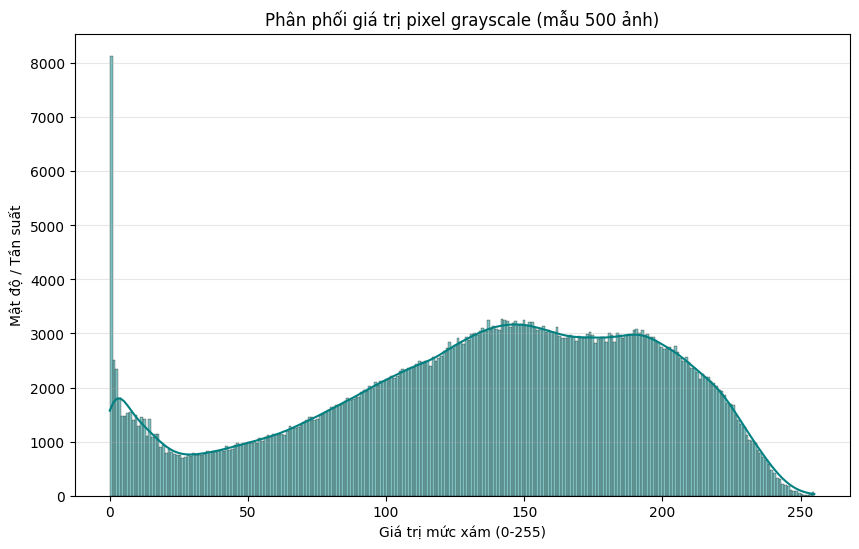

In [48]:
def sample_grayscale_pixels(
    df: pd.DataFrame,
    image_dir: Path,
    num_samples: int = 500,
    pixels_per_image: int = 1000,
    random_state: int = 42,
) -> np.ndarray:
    sampled_names = df.sample(n=min(num_samples, len(df)), random_state=random_state)["Image Index"]
    pixel_values = []

    rng = np.random.default_rng(random_state)
    for img_name in sampled_names:
        path = image_dir / img_name
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        flat_img = img.flatten()
        sample_size = min(pixels_per_image, len(flat_img))
        sampled = rng.choice(flat_img, size=sample_size, replace=False)
        pixel_values.extend(sampled.tolist())

    return np.asarray(pixel_values, dtype=np.float32)


hist_num_samples = 500
hist_pixels_per_image = 1000
pixel_data_sampled = sample_grayscale_pixels(
    df=df_final,
    image_dir=IMAGE_DIR,
    num_samples=hist_num_samples,
    pixels_per_image=hist_pixels_per_image,
    random_state=SEED,
)

hist_pixel_mean = float(pixel_data_sampled.mean())
hist_pixel_std = float(pixel_data_sampled.std())
hist_pixel_min = float(pixel_data_sampled.min())
hist_pixel_max = float(pixel_data_sampled.max())

print_named_metric("hist_num_samples", hist_num_samples)
print_named_metric("hist_pixels_per_image", hist_pixels_per_image)
print_named_metric("hist_pixel_mean", round(hist_pixel_mean, 4))
print_named_metric("hist_pixel_std", round(hist_pixel_std, 4))
print_named_metric("hist_pixel_min", hist_pixel_min)
print_named_metric("hist_pixel_max", hist_pixel_max)

plt.figure(figsize=(10, 6))
sns.histplot(pixel_data_sampled, bins=256, kde=True, color="teal")
plt.title(f"Phân phối giá trị pixel grayscale (mẫu {hist_num_samples} ảnh)")
plt.xlabel("Giá trị mức xám (0-255)")
plt.ylabel("Mật độ / Tần suất")
plt.grid(axis="y", alpha=0.3)
plt.show()

Histogram và KDE cho thấy phân phối cường độ của ảnh X-quang tập trung ở miền xám trung bình, phù hợp với cấu trúc giải phẫu ngực (nhiều vùng mô mềm và khí phổi đồng thời tồn tại). Việc chỉ dùng một kênh grayscale giúp phân phối phản ánh đúng thông tin vật lý của ảnh, thay vì tạo ba phân phối RGB lặp thông tin và làm sai lệch diễn giải thống kê.

#### **b) Mất cân bằng lớp**
Mất cân bằng lớp xảy ra khi số mẫu giữa các lớp chênh lệch lớn. Với bài toán đa lớp, một chỉ số nhanh là:

$$\text{Imbalance Ratio} = \frac{\max_c n_c}{\min_c n_c}$$

Trong đó $n_c$ là số mẫu của lớp $c$. 

min_count: 355
max_count: 1818
imbalance_max_ratio: 5.1211
num_classes_over_3x: 1
classes_over_3x: ['Infiltration']
imbalance_table:
          class  count  ratio_vs_min
0   Atelectasis    944      2.659155
1  Cardiomegaly    355      1.000000
2      Effusion    791      2.228169
3  Infiltration   1818      5.121127
4          Mass    361      1.016901
5        Nodule    612      1.723944
6  Pneumothorax    482      1.357746


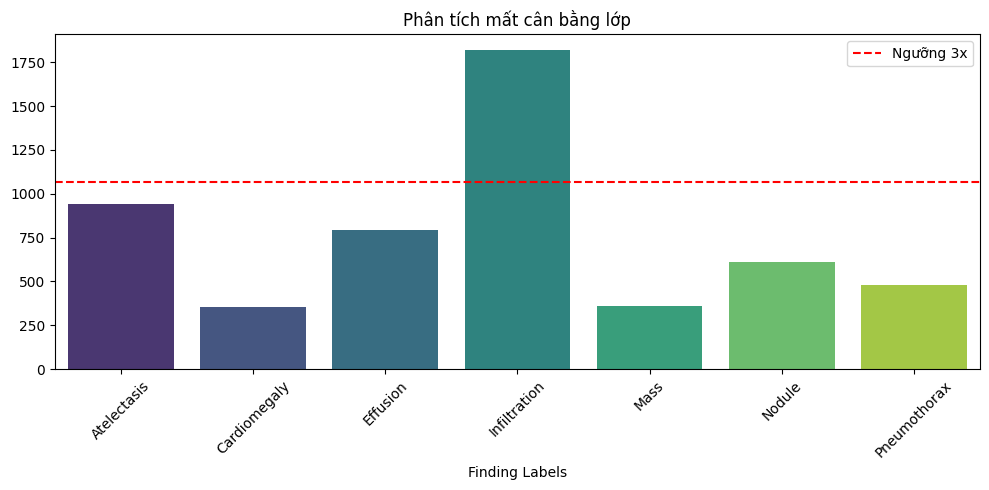

In [49]:
class_counts = df_final["Finding Labels"].value_counts().sort_index()
min_count = int(class_counts.min())
max_count = int(class_counts.max())
imbalance_ratios = class_counts / min_count
imbalance_max_ratio = float(imbalance_ratios.max())
classes_over_3x = imbalance_ratios[imbalance_ratios > 3.0].index.tolist()

print_named_metric("min_count", min_count)
print_named_metric("max_count", max_count)
print_named_metric("imbalance_max_ratio", round(imbalance_max_ratio, 4))
print_named_metric("num_classes_over_3x", len(classes_over_3x))
print_named_metric("classes_over_3x", classes_over_3x)

imbalance_table = pd.DataFrame({
    "class": class_counts.index,
    "count": class_counts.values,
    "ratio_vs_min": imbalance_ratios.values,
})
print("imbalance_table:")
print(imbalance_table)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette="viridis",
    legend=False,
)
plt.axhline(y=min_count * 3, color="red", linestyle="--", label="Ngưỡng 3x")
plt.title("Phân tích mất cân bằng lớp")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Giá trị `imbalance_max_ratio` vượt ngưỡng $3\times$, chứng tỏ mất cân bằng lớp là đáng kể, làm độ chính xác tổng thể.

#### **c) Perceptual Hash (pHash)**
pHash là hàm băm cảm nhận dựa trên nội dung ảnh, ổn định trước các biến đổi nhẹ (độ sáng, kích thước). Ý tưởng chính:
1. Chuẩn hóa kích thước ảnh.
2. Biến đổi DCT để lấy thành phần tần số thấp.
3. So sánh từng hệ số với giá trị trung bình để tạo bit hash.

Nếu hai ảnh có hash trùng nhau, khả năng rất cao là ảnh trùng hoặc gần trùng.

In [50]:
from collections import defaultdict

# =========================
# 1. pHash chuẩn (64-bit int)
# =========================

def calculate_phash(img_path: Path) -> int | None:
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # Resize
    img = cv2.resize(img, (32, 32), interpolation=cv2.INTER_AREA)

    # DCT
    dct = cv2.dct(np.float32(img))

    # Low-frequency 8x8
    dct_low = dct[:8, :8].flatten()

    # Bỏ DC component
    dct_no_dc = dct_low[1:]

    avg = dct_no_dc.mean()

    # Encode thành 64-bit int
    bits = (dct_no_dc > avg).astype(np.uint8)

    hash_val = 0
    for b in bits:
        hash_val = (hash_val << 1) | int(b)

    return hash_val


# =========================
# 2. Hamming distance
# =========================
def hamming_distance(h1: int, h2: int) -> int:
    return (h1 ^ h2).bit_count()


# =========================
# 3. Prefix indexing (tối ưu)
# =========================
def get_prefix(hash_val: int, bits=20):
    return hash_val >> (64 - bits)


# =========================
# 4. Find duplicates (optimized)
# =========================
def find_duplicates_phash(df, image_dir, threshold=4, prefix_bits=20):
    buckets = defaultdict(list)

    duplicate_pairs = []
    duplicate_image_names = set()

    for img_name in df["Image Index"]:
        img_path = image_dir / img_name
        if not img_path.exists():
            continue

        phash = calculate_phash(img_path)
        if phash is None:
            continue

        prefix = get_prefix(phash, prefix_bits)

        candidates = buckets[prefix]
        found_duplicate = False

        for existing_hash, existing_name in candidates:
            if hamming_distance(phash, existing_hash) <= threshold:
                duplicate_pairs.append((existing_name, img_name))
                duplicate_image_names.add(img_name)
                found_duplicate = True
                break

        if not found_duplicate:
            buckets[prefix].append((phash, img_name))

    return duplicate_pairs, duplicate_image_names


# =========================
# 5. RUN PIPELINE
# =========================
duplicate_pairs, duplicate_image_names = find_duplicates_phash(
    df_final,
    IMAGE_DIR,
    threshold=4, 
    prefix_bits=20     
)

# =========================
# 6. Mark + Remove duplicates
# =========================
df_final_marked = df_final.copy()
df_final_marked["is_duplicate"] = df_final_marked["Image Index"].isin(duplicate_image_names)

df_dedup = df_final_marked[~df_final_marked["is_duplicate"]].copy().reset_index(drop=True)

# Dataset dùng downstream
df_working = df_dedup.copy()

# =========================
# 7. Metrics
# =========================
num_duplicates = int(len(duplicate_pairs))
num_total = int(len(df_final))
duplicate_ratio_pct = float((num_duplicates / num_total) * 100) if num_total else 0.0

size_before_dedup = int(len(df_final_marked))
size_after_dedup = int(len(df_dedup))
num_removed_duplicates = int(size_before_dedup - size_after_dedup)

# =========================
# 8. Output
# =========================
def print_named_metric(name, value):
    print(f"{name}: {value}")

print_named_metric("num_duplicates", num_duplicates)
print_named_metric("duplicate_ratio_pct", round(duplicate_ratio_pct, 6))
print_named_metric("size_before_dedup", size_before_dedup)
print_named_metric("size_after_dedup", size_after_dedup)
print_named_metric("num_removed_duplicates", num_removed_duplicates)

# Bảng size
dedup_size_table = pd.DataFrame({
    "dataset_state": ["before_dedup", "after_dedup"],
    "num_images": [size_before_dedup, size_after_dedup],
})

print("\ndedup_size_table:")
print(dedup_size_table)

# Ví dụ duplicate
duplicate_examples = pd.DataFrame(duplicate_pairs[:10], columns=["first_seen", "duplicate"])

num_duplicates: 357
duplicate_ratio_pct: 6.656722
size_before_dedup: 5363
size_after_dedup: 5006
num_removed_duplicates: 357

dedup_size_table:
  dataset_state  num_images
0  before_dedup        5363
1   after_dedup        5006


# Phân tích kết quả

## 1. Thiết lập phương pháp

Trong bước tiền xử lý dữ liệu, phương pháp **pHash** được sử dụng để phát hiện và loại bỏ các ảnh trùng lặp hoặc gần trùng lặp.

Cấu hình được lựa chọn:
- **Hamming distance threshold = 4**
- **Prefix indexing = 20 bits**

---

## 2. Kết quả thu được

- Tổng số ảnh ban đầu: **5363**
- Số ảnh trùng lặp phát hiện: **357**
- Tỷ lệ ảnh trùng lặp: **6.66%**
- Số ảnh sau khi loại bỏ: **5006**

---

## 3. Phân tích kết quả

Tỷ lệ **6.66%** cho thấy dataset có tồn tại một lượng ảnh trùng lặp hoặc gần trùng lặp ở mức **vừa phải**.

Nguyên nhân có thể là:
- Dữ liệu được tổng hợp từ nhiều nguồn khác nhau
- Có thể tồn tại ảnh lặp trong quá trình thu thập
- Một số ảnh chỉ khác biệt nhỏ (độ sáng, nhiễu, crop nhẹ)

---

## 4. Tác động đến dataset

Sau khi loại bỏ ảnh trùng lặp:

- Dataset giảm từ 5363 → 5006 ảnh
- Loại bỏ 357 ảnh dư thừa

Lợi ích:
- Giảm dữ liệu lặp
- Tránh bias khi huấn luyện
- Cải thiện hiệu quả và tốc độ huấn luyện mô hình

---

## 5. Kết luận

Phương pháp pHash với cấu hình đã chọn:

- Xác định hiệu quả các ảnh trùng lặp trong dataset
- Đạt được sự cân bằng hợp lý giữa **precision và recall**
- Bảo toàn phần lớn dữ liệu đa dạng

Tỷ lệ loại bỏ **6.66%** phản ánh đúng đặc điểm của dataset và cho thấy:
> Quá trình tiền xử lý là hiệu quả và đáng tin cậy.

---

#### **d) Mean và Standard Deviation theo lớp**
Với ảnh grayscale:
- Mean intensity ($\mu$) -> mức sáng trung bình.
- Standard deviation ($\sigma$) -> độ phân tán cường độ

So sánh boxplot giữa các lớp giúp phát hiện khác biệt phân phối và các outliers giúp hỗ trợ quyết định tiền xử lý.


mean_by_class:
label
Mass            143.360288
Nodule          140.777554
Atelectasis     136.921437
Effusion        135.776622
Cardiomegaly    133.356996
Pneumothorax    128.041783
Infiltration    127.498314
Name: mean_intensity, dtype: float64
std_by_class:
label
Cardiomegaly    59.358604
Pneumothorax    59.056225
Infiltration    57.478815
Effusion        56.984622
Atelectasis     55.112849
Mass            54.229978
Nodule          54.062958
Name: std_intensity, dtype: float64


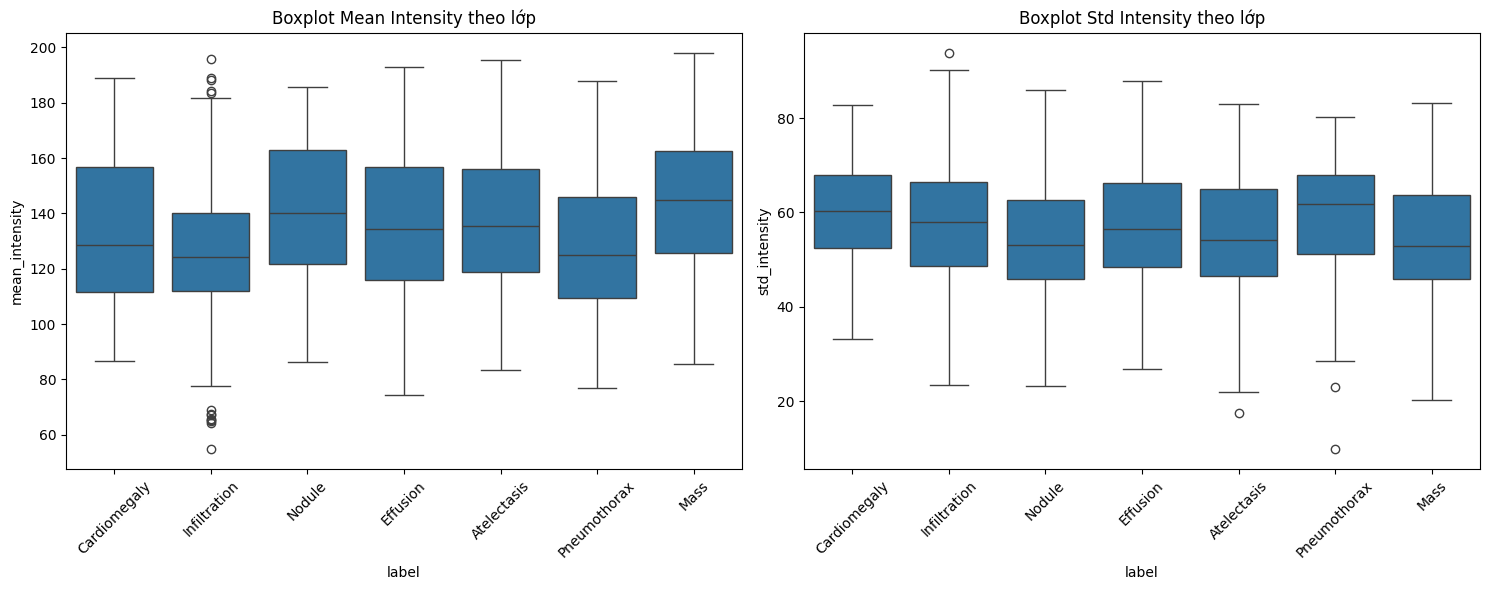

In [51]:
image_stats_records = []

for _, row in df_working.iterrows():
    img_path = IMAGE_DIR / row["Image Index"]
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    image_stats_records.append(
        {
            "label": row["Finding Labels"],
            "mean_intensity": float(img.mean()),
            "std_intensity": float(img.std()),
        }
    )

df_stats = pd.DataFrame(image_stats_records)

mean_by_class = df_stats.groupby("label")["mean_intensity"].mean().sort_values(ascending=False)
std_by_class = df_stats.groupby("label")["std_intensity"].mean().sort_values(ascending=False)

print("mean_by_class:")
print(mean_by_class)
print("std_by_class:")
print(std_by_class)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x="label", y="mean_intensity", data=df_stats)
plt.xticks(rotation=45)
plt.title("Boxplot Mean Intensity theo lớp")

plt.subplot(1, 2, 2)
sns.boxplot(x="label", y="std_intensity", data=df_stats)
plt.xticks(rotation=45)
plt.title("Boxplot Std Intensity theo lớp")

plt.tight_layout()
plt.show()

# Phân tích Boxplot Mean & Std Intensity theo lớp

## 1. Mô tả chung

Hai biểu đồ boxplot thể hiện phân bố của **Mean intensity** (cường độ sáng trung bình) và **Standard deviation intensity (std)** (độ biến thiên cường độ sáng) theo từng lớp bệnh: Cardiomegaly, Infiltration, Nodule, Effusion, Atelectasis, Pneumothorax, Mass

---

## 2. Phân tích Mean Intensity

### 2.1. So sánh trung vị

- Các lớp như **Mass, Nodule, Atelectasis** có median cao hơn (~135–145)
- Các lớp như **Infiltration, Pneumothorax** có median thấp hơn (~120–130)

> Một số lớp có xu hướng ảnh sáng hơn (intensity cao hơn) so với các lớp khác

---

### 2.2. Độ phân tán (IQR và whiskers)

- Hầu hết các lớp có khoảng giá trị rộng (~80 → ~190)
- Các box khá lớn → dữ liệu có **độ biến thiên cao**

> Mean intensity **không phải là đặc trưng phân biệt mạnh** giữa các lớp

---

### 2.3. Outliers

- Lớp **Infiltration** xuất hiện nhiều outliers:
  - Rất thấp (~50–70)
  - Rất cao (~180–195)

Cho thấy:
- Dataset của lớp này **không đồng nhất**
- Có thể chứa nhiều điều kiện chụp khác nhau

---

## 3. Phân tích Std Intensity

### 3.1. So sánh trung vị

- Các lớp có std tương đối gần nhau (~50–65)
- **Pneumothorax, Cardiomegaly** có xu hướng std cao hơn
- **Nodule, Mass** thấp hơn một chút

> Độ biến thiên pixel giữa các lớp **không khác biệt rõ rệt**

---

### 3.2. Độ phân tán

- Std intensity dao động trong khoảng:
  - ~20 → ~90
- Các box có kích thước tương đương nhau

> Các lớp có mức độ tương phản khá tương đồng

---

### 3.3. Outliers

- Xuất hiện ở nhiều lớp:
  - Pneumothorax có outlier rất thấp (~10)
  - Atelectasis có outlier thấp (~17)

Cho thấy:
- Một số ảnh có độ tương phản rất thấp hoặc rất cao
- Có thể do được chụp bởi các thiết bị khác nhau.

---

## 5. Kết luận

- Dataset có:
  - Độ biến thiên cường độ sáng cao
  - Sự khác biệt giữa các lớp không rõ ràng về mặt intensity

- Các đặc trưng thống kê đơn giản (mean, std):
  - Không phản ánh đầy đủ đặc trưng bệnh lý
  - Cần kết hợp với các đặc trưng nâng cao hơn (texture, deep features)

#### **2.1.3. Các kỹ thuật tiền xử lý và phân tích tác động**


#### **a) Thay đổi kích thước (Resize) và định lượng mất mát thông tin**
Ảnh y tế có độ phân giải lớn, nên cần resize để giảm chi phí tính toán. Tuy nhiên, resize có thể làm mất chi tiết bệnh lý. Để định lượng tổn thất thông tin, dùng:

1. **PSNR (Peak Signal-to-Noise Ratio):**
$$PSNR = 10 \cdot \log_{10}\left(\frac{MAX_I^2}{MSE}\right)$$
Trong đó $MAX_I = 255$.

2. **SSIM (Structural Similarity Index):**
$$SSIM(x, y) = \frac{(2\mu_x\mu_y + c_1)(2\sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1)(\sigma_x^2 + \sigma_y^2 + c_2)}$$

Đoạn code này đánh giá PSNR/SSIM khi resize về $32\times32$, $64\times64$, $128\times128$, sau đó upscale ngược để so sánh với ảnh gốc.

In [52]:
def load_image_dict(df: pd.DataFrame, image_dir: Path) -> dict[str, np.ndarray]:
    """Load grayscale images into a dict keyed by image name."""
    image_dict = {}
    for img_name in df["Image Index"]:
        img_path = image_dir / img_name
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            image_dict[img_name] = img
    return image_dict


def resize_images(image_dict: dict[str, np.ndarray], size: tuple[int, int]) -> dict[str, np.ndarray]:
    return {
        name: cv2.resize(img, size, interpolation=cv2.INTER_AREA)
        for name, img in image_dict.items()
    }


def normalize_images(image_dict: dict[str, np.ndarray], method: str = "zscore_per_image") -> dict[str, np.ndarray]:
    normalized = {}
    for name, img in image_dict.items():
        img_f = img.astype(np.float32)
        if method == "minmax_01":
            out = (img_f - img_f.min()) / (img_f.max() - img_f.min() + 1e-8)
        elif method == "minmax_11":
            mm = (img_f - img_f.min()) / (img_f.max() - img_f.min() + 1e-8)
            out = 2.0 * mm - 1.0
        elif method == "zscore_global":
            raise ValueError("zscore_global requires global statistics and is handled separately.")
        else:
            out = (img_f - img_f.mean()) / (img_f.std() + 1e-8)
        normalized[name] = out
    return normalized


def transform_color_space(image_dict: dict[str, np.ndarray], mode: str = "grayscale") -> dict[str, np.ndarray]:
    transformed = {}
    for name, img in image_dict.items():
        if mode == "grayscale":
            transformed[name] = img.copy()
        elif mode == "lab_l":
            img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
            transformed[name] = img_lab[:, :, 0]
        else:
            raise ValueError(f"Unsupported color mode: {mode}")
    return transformed


def augment_data(
    image_dict: dict[str, np.ndarray],
    labels_df: pd.DataFrame,
    target_ratio: float = 2.0,
    random_state: int = 42,
) -> tuple[dict[str, np.ndarray], pd.DataFrame]:
    """Augment minority classes in-memory until max/min <= target_ratio."""
    rng = random.Random(random_state)
    augmented = dict(image_dict)
    labels_aug = labels_df[["Image Index", "Finding Labels"]].copy()

    class_counts_local = labels_aug["Finding Labels"].value_counts()
    max_count_local = int(class_counts_local.max())
    target_min_count = int(np.ceil(max_count_local / target_ratio))

    for label, count in class_counts_local.items():
        if count >= target_min_count:
            continue

        need = target_min_count - int(count)
        source_names = labels_aug.loc[labels_aug["Finding Labels"] == label, "Image Index"].tolist()
        for aug_idx in range(need):
            src_name = rng.choice(source_names)
            src_img = augmented[src_name]

            angle = rng.uniform(-10, 10)
            alpha = rng.uniform(0.85, 1.15)
            beta = rng.uniform(-15, 15)

            h, w = src_img.shape
            rot_m = cv2.getRotationMatrix2D((w / 2.0, h / 2.0), angle, 1.0)
            rot_img = cv2.warpAffine(src_img, rot_m, (w, h), borderMode=cv2.BORDER_REFLECT)
            aug_img = cv2.convertScaleAbs(rot_img, alpha=alpha, beta=beta)

            new_name = f"aug_{label}_{aug_idx}_{src_name}"
            augmented[new_name] = aug_img
            labels_aug.loc[len(labels_aug)] = [new_name, label]

    return augmented, labels_aug


def extract_features(image_dict: dict[str, np.ndarray], image_names: list[str]) -> np.ndarray:
    features = [image_dict[name].astype(np.float32).flatten() for name in image_names if name in image_dict]
    return np.asarray(features, dtype=np.float32)


shared_image_dict = load_image_dict(df_working, IMAGE_DIR)
shared_loaded_images = int(len(shared_image_dict))
print_named_metric("shared_loaded_images", shared_loaded_images)

shared_loaded_images: 5006


resize_eval_sample_size: 30
ssim_32: 0.899235
ssim_64: 0.917391
ssim_128: 0.936123
psnr_32: 28.930889
psnr_64: 32.066946
psnr_128: 34.919275
df_resize_quality:
      size  psnr_mean  ssim_mean
0    32x32  28.930889   0.899235
1    64x64  32.066946   0.917391
2  128x128  34.919275   0.936123


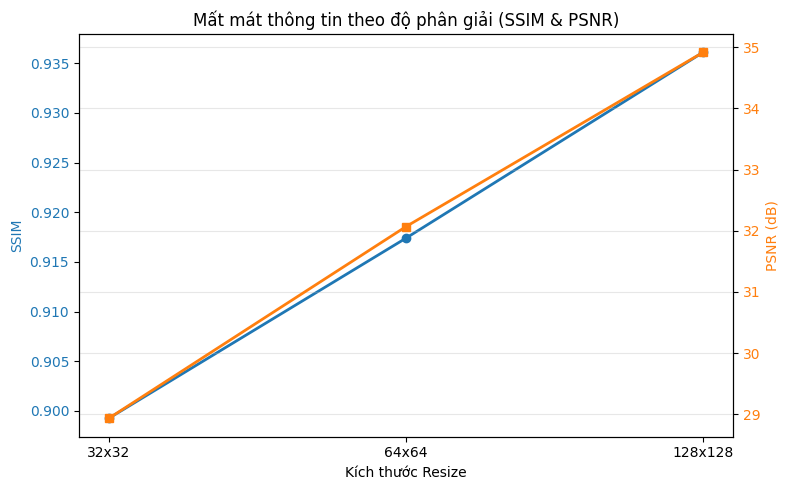

In [53]:
def calculate_ssim(img1: np.ndarray, img2: np.ndarray) -> float:
    c1 = (0.01 * 255) ** 2
    c2 = (0.03 * 255) ** 2

    x = img1.astype(np.float64)
    y = img2.astype(np.float64)

    kernel = cv2.getGaussianKernel(11, 1.5)
    window = np.outer(kernel, kernel.transpose())

    mu_x = cv2.filter2D(x, -1, window)[5:-5, 5:-5]
    mu_y = cv2.filter2D(y, -1, window)[5:-5, 5:-5]

    mu_x2 = mu_x ** 2
    mu_y2 = mu_y ** 2
    mu_xy = mu_x * mu_y

    sigma_x2 = cv2.filter2D(x ** 2, -1, window)[5:-5, 5:-5] - mu_x2
    sigma_y2 = cv2.filter2D(y ** 2, -1, window)[5:-5, 5:-5] - mu_y2
    sigma_xy = cv2.filter2D(x * y, -1, window)[5:-5, 5:-5] - mu_xy

    ssim_map = ((2 * mu_xy + c1) * (2 * sigma_xy + c2)) / ((mu_x2 + mu_y2 + c1) * (sigma_x2 + sigma_y2 + c2))
    return float(ssim_map.mean())


resize_eval_sample_size = min(30, len(df_working))
resize_eval_sizes = [32, 64, 128]
resize_eval_names = df_working.sample(n=resize_eval_sample_size, random_state=SEED)["Image Index"].tolist()

resize_quality_records = []
for size in resize_eval_sizes:
    stage_psnr_values = []
    stage_ssim_values = []

    for img_name in resize_eval_names:
        original = shared_image_dict.get(img_name)
        if original is None:
            continue

        h, w = original.shape
        downscaled = cv2.resize(original, (size, size), interpolation=cv2.INTER_AREA)
        restored = cv2.resize(downscaled, (w, h), interpolation=cv2.INTER_CUBIC)

        stage_psnr_values.append(float(cv2.PSNR(original, restored)))
        stage_ssim_values.append(calculate_ssim(original, restored))

    resize_quality_records.append(
        {
            "size": f"{size}x{size}",
            "psnr_mean": float(np.mean(stage_psnr_values)),
            "ssim_mean": float(np.mean(stage_ssim_values)),
        }
    )

df_resize_quality = pd.DataFrame(resize_quality_records)

ssim_32 = float(df_resize_quality.loc[df_resize_quality["size"] == "32x32", "ssim_mean"].iloc[0])
ssim_64 = float(df_resize_quality.loc[df_resize_quality["size"] == "64x64", "ssim_mean"].iloc[0])
ssim_128 = float(df_resize_quality.loc[df_resize_quality["size"] == "128x128", "ssim_mean"].iloc[0])

psnr_32 = float(df_resize_quality.loc[df_resize_quality["size"] == "32x32", "psnr_mean"].iloc[0])
psnr_64 = float(df_resize_quality.loc[df_resize_quality["size"] == "64x64", "psnr_mean"].iloc[0])
psnr_128 = float(df_resize_quality.loc[df_resize_quality["size"] == "128x128", "psnr_mean"].iloc[0])

print_named_metric("resize_eval_sample_size", resize_eval_sample_size)
print_named_metric("ssim_32", round(ssim_32, 6))
print_named_metric("ssim_64", round(ssim_64, 6))
print_named_metric("ssim_128", round(ssim_128, 6))
print_named_metric("psnr_32", round(psnr_32, 6))
print_named_metric("psnr_64", round(psnr_64, 6))
print_named_metric("psnr_128", round(psnr_128, 6))
print("df_resize_quality:")
print(df_resize_quality)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xlabel("Kích thước Resize")
ax1.set_ylabel("SSIM", color="tab:blue")
ax1.plot(df_resize_quality["size"], df_resize_quality["ssim_mean"], marker="o", color="tab:blue", linewidth=2)
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("PSNR (dB)", color="tab:orange")
ax2.plot(df_resize_quality["size"], df_resize_quality["psnr_mean"], marker="s", color="tab:orange", linewidth=2)
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Mất mát thông tin theo độ phân giải (SSIM & PSNR)")
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

Giá trị `ssim_128` và `psnr_128` cao nhất cho thấy mức bảo toàn cấu trúc tốt nhất ở $128\times128$. Mức $32\times32$ suy giảm mạnh cả SSIM và PSNR, hàm ý nguy cơ mất chi tiết bất thường nhỏ. Vì vậy, chọn kích thước chuẩn `128x128` để cân bằng giữa hiệu năng tính toán và bảo toàn thông tin y khoa.

#### **b) Không gian màu và phương sai giải thích (PCA)**

PCA đo mức độ thông tin giữ lại khi chiếu dữ liệu lên không gian chiều thấp. Trong bài này, so sánh theo cùng cấu hình **k = 50** thành phần chính (hoặc fallback về số nhỏ hơn khi dữ liệu không đủ mẫu/chiều).

Để so sánh công bằng giữa các không gian màu, đặc trưng được chuẩn hóa z-score theo từng chiều trước khi fit PCA. Tổng explained variance ratio càng cao thì mức cô đọng thông tin càng tốt.

Trong ảnh X-quang, thông tin bệnh lý chủ yếu nằm ở cường độ sáng. Vì vậy cần kiểm chứng định lượng xem Grayscale có hiệu quả hơn các không gian 3 kênh (RGB/HSV/LAB) hay không.


pca_sample_size: 1000
pca_resize_dim: 64
pca_target_k: 50
gray_explained_variance_pct: 91.261635
rgb_explained_variance_pct: 91.261665
hsv_explained_variance_pct: 91.261642
lab_explained_variance_pct: 91.021378
df_pca_results:
  color_space  used_k  explained_variance_pct
1         RGB      50               91.261665
2         HSV      50               91.261642
0   Grayscale      50               91.261635
3         LAB      50               91.021378


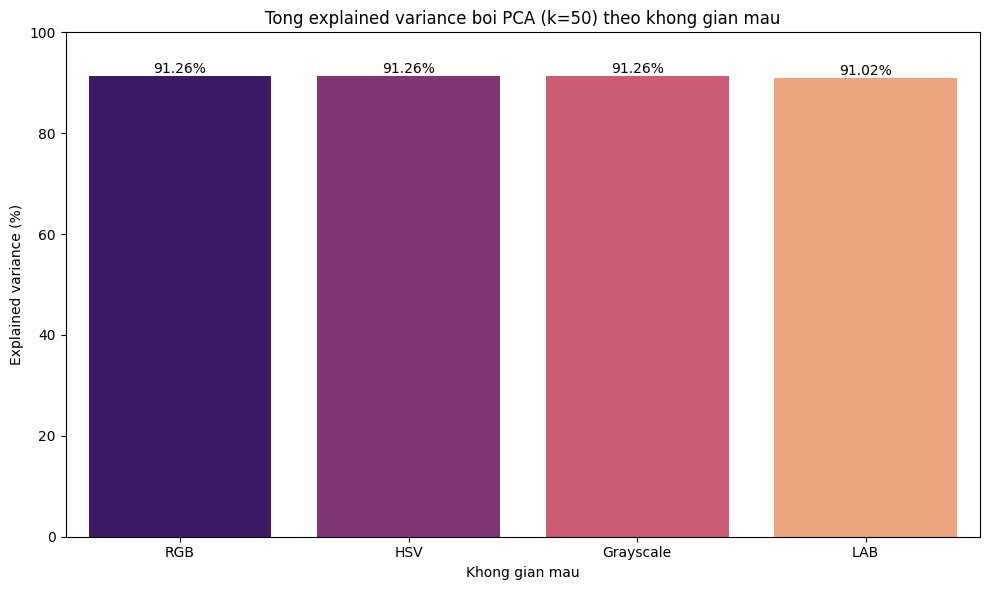

In [54]:
pca_sample_size = min(1000, len(df_working))
pca_resize_dim = 64
pca_target_k = 50
pca_sample_names = df_working.sample(n=pca_sample_size, random_state=SEED)["Image Index"].tolist()

color_features = {
    "Grayscale": [],
    "RGB": [],
    "HSV": [],
    "LAB": [],
}

for img_name in pca_sample_names:
    img_gray = shared_image_dict.get(img_name)
    if img_gray is None:
        continue

    img_gray_resized = cv2.resize(img_gray, (pca_resize_dim, pca_resize_dim), interpolation=cv2.INTER_AREA)
    img_bgr = cv2.cvtColor(img_gray_resized, cv2.COLOR_GRAY2BGR)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

    color_features["Grayscale"].append(img_gray_resized.flatten().astype(np.float32))
    color_features["RGB"].append(img_rgb.flatten().astype(np.float32))
    color_features["HSV"].append(img_hsv.flatten().astype(np.float32))
    color_features["LAB"].append(img_lab.flatten().astype(np.float32))


def zscore_features(x: np.ndarray) -> np.ndarray:
    feature_mean = x.mean(axis=0, keepdims=True)
    feature_std = x.std(axis=0, keepdims=True)
    return (x - feature_mean) / (feature_std + 1e-8)


pca_results = {}
pca_used_k = {}
for color_space, features in color_features.items():
    x = np.asarray(features, dtype=np.float32)
    if len(x) == 0:
        continue

    x_std = zscore_features(x)
    n_components = min(pca_target_k, x_std.shape[0], x_std.shape[1])
    pca = PCA(n_components=n_components, random_state=SEED)
    pca.fit(x_std)

    pca_results[color_space] = float(np.sum(pca.explained_variance_ratio_) * 100.0)
    pca_used_k[color_space] = int(n_components)

df_pca_results = pd.DataFrame(
    {
        "color_space": list(pca_results.keys()),
        "used_k": [pca_used_k[c] for c in pca_results.keys()],
        "explained_variance_pct": list(pca_results.values()),
    }
).sort_values("explained_variance_pct", ascending=False)

gray_explained_variance_pct = float(pca_results.get("Grayscale", np.nan))
rgb_explained_variance_pct = float(pca_results.get("RGB", np.nan))
hsv_explained_variance_pct = float(pca_results.get("HSV", np.nan))
lab_explained_variance_pct = float(pca_results.get("LAB", np.nan))

print_named_metric("pca_sample_size", pca_sample_size)
print_named_metric("pca_resize_dim", pca_resize_dim)
print_named_metric("pca_target_k", pca_target_k)
print_named_metric("gray_explained_variance_pct", round(gray_explained_variance_pct, 6))
print_named_metric("rgb_explained_variance_pct", round(rgb_explained_variance_pct, 6))
print_named_metric("hsv_explained_variance_pct", round(hsv_explained_variance_pct, 6))
print_named_metric("lab_explained_variance_pct", round(lab_explained_variance_pct, 6))
print("df_pca_results:")
print(df_pca_results)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_pca_results,
    x="color_space",
    y="explained_variance_pct",
    hue="color_space",
    palette="magma",
    legend=False,
)
for bar in ax.patches:
    height = bar.get_height()
    plt.annotate(
        f"{height:.2f}%",
        (bar.get_x() + bar.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.title("Tong explained variance boi PCA (k=50) theo khong gian mau")
plt.xlabel("Khong gian mau")
plt.ylabel("Explained variance (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Kết quả cho thấy tổng phương sai được giải thích bởi 50 thành phần PCA giữa các không gian màu (Grayscale, RGB, HSV, LAB) là tương đối gần nhau.

Sau khi chuẩn hóa dữ liệu trước PCA, sự khác biệt giữa các không gian màu phản ánh chính xác hơn khả năng biểu diễn thông tin thay vì bị ảnh hưởng bởi thang đo giá trị pixel.

### Nhận xét:

- Không gian màu có explained variance cao hơn cho thấy khả năng nén thông tin tốt hơn với số chiều thấp (k = 50).
- Tuy nhiên, sự chênh lệch giữa các không gian màu không lớn.
- Do dữ liệu gốc là ảnh X-ray (grayscale), việc chuyển sang RGB, HSV hoặc LAB không tạo thêm thông tin mới mà chỉ biến đổi biểu diễn.

### Kết luận:

- Grayscale đã đủ để biểu diễn thông tin chính của ảnh.
- Các không gian màu khác không mang lại lợi ích đáng kể cho bài toán phân loại.
- Do đó, sử dụng Grayscale giúp giảm chi phí tính toán mà vẫn giữ được hiệu quả.

> Không gian màu tốt nhất trong ngữ cảnh này là Grayscale do tính đơn giản và hiệu quả tương đương.

#### **c) Chuẩn hóa và kiểm định Kolmogorov-Smirnov (KS test)**

Các phương pháp:
1. Min-Max [0, 1]: $X' = \frac{X - X_{min}}{X_{max} - X_{min}}$
2. Min-Max [-1, 1]: $X' = 2\cdot\frac{X - X_{min}}{X_{max} - X_{min}} - 1$
3. Z-score toàn tập: $X' = \frac{X - \mu_{global}}{\sigma_{global}}$
4. Z-score từng ảnh: $X' = \frac{X - \mu_{img}}{\sigma_{img}}$

KS test so sánh hai phân phối:
- $H_0$: hai mẫu cùng phân phối.
- Nếu p-value < 0.05: bác bỏ $H_0$.

In [55]:
norm_num_images = min(500, len(df_working))
norm_pixels_per_image = 1000
norm_sample_names = df_working.sample(n=norm_num_images, random_state=SEED)["Image Index"].tolist()

original_sampled = []
zscore_local_sampled = []
rng_norm = np.random.default_rng(SEED)

for img_name in norm_sample_names:
    img = shared_image_dict.get(img_name)
    if img is None:
        continue

    flat_img = img.flatten().astype(np.float32)
    sample_size = min(norm_pixels_per_image, len(flat_img))
    sample_idx = rng_norm.choice(len(flat_img), size=sample_size, replace=False)
    sampled_pixels = flat_img[sample_idx]

    original_sampled.extend(sampled_pixels.tolist())

    local_mean = float(img.mean())
    local_std = float(img.std())
    z_local = (sampled_pixels - local_mean) / (local_std + 1e-8)
    zscore_local_sampled.extend(z_local.tolist())

original_sampled = np.asarray(original_sampled, dtype=np.float32)
zscore_local_sampled = np.asarray(zscore_local_sampled, dtype=np.float32)

global_min = float(original_sampled.min())
global_max = float(original_sampled.max())
global_mean = float(original_sampled.mean())
global_std = float(original_sampled.std())

minmax_01_sampled = (original_sampled - global_min) / (global_max - global_min + 1e-8)
minmax_11_sampled = 2.0 * minmax_01_sampled - 1.0
zscore_global_sampled = (original_sampled - global_mean) / (global_std + 1e-8)

ks_test_size = min(10000, len(original_sampled))
test_indices = rng_norm.choice(len(original_sampled), size=ks_test_size, replace=False)

sample_orig = original_sampled[test_indices]
sample_01 = minmax_01_sampled[test_indices]
sample_11 = minmax_11_sampled[test_indices]
sample_z_global = zscore_global_sampled[test_indices]
sample_z_local = zscore_local_sampled[test_indices]

norm_methods = {
    "Min-Max [0, 1]": sample_01,
    "Min-Max [-1, 1]": sample_11,
    "Z-score (Toan tap)": sample_z_global,
    "Z-score (Tung anh)": sample_z_local,
}

ks_results = []
for method_name, norm_data in norm_methods.items():
    ks_stat, p_value = ks_2samp(sample_orig, norm_data)
    ks_results.append(
        {
            "method": method_name,
            "ks_statistic": float(ks_stat),
            "p_value": float(p_value),
        }
    )

df_ks_results = pd.DataFrame(ks_results)

ks_stat_minmax_01 = float(df_ks_results.loc[df_ks_results["method"] == "Min-Max [0, 1]", "ks_statistic"].iloc[0])
ks_pvalue_minmax_01 = float(df_ks_results.loc[df_ks_results["method"] == "Min-Max [0, 1]", "p_value"].iloc[0])
ks_stat_minmax_11 = float(df_ks_results.loc[df_ks_results["method"] == "Min-Max [-1, 1]", "ks_statistic"].iloc[0])
ks_pvalue_minmax_11 = float(df_ks_results.loc[df_ks_results["method"] == "Min-Max [-1, 1]", "p_value"].iloc[0])
ks_stat_zglobal = float(df_ks_results.loc[df_ks_results["method"] == "Z-score (Toan tap)", "ks_statistic"].iloc[0])
ks_pvalue_zglobal = float(df_ks_results.loc[df_ks_results["method"] == "Z-score (Toan tap)", "p_value"].iloc[0])
ks_stat_zlocal = float(df_ks_results.loc[df_ks_results["method"] == "Z-score (Tung anh)", "ks_statistic"].iloc[0])
ks_pvalue_zlocal = float(df_ks_results.loc[df_ks_results["method"] == "Z-score (Tung anh)", "p_value"].iloc[0])

print_named_metric("norm_num_images", norm_num_images)
print_named_metric("norm_pixels_per_image", norm_pixels_per_image)
print_named_metric("ks_test_size", ks_test_size)
print("df_ks_results:")
print(df_ks_results)

norm_num_images: 500
norm_pixels_per_image: 1000
ks_test_size: 10000
df_ks_results:
               method  ks_statistic  p_value
0      Min-Max [0, 1]        0.9800      0.0
1     Min-Max [-1, 1]        0.9800      0.0
2  Z-score (Toan tap)        0.9762      0.0
3  Z-score (Tung anh)        0.9756      0.0


Khi các `ks_pvalue_* < 0.05`, ta bác bỏ $H_0$ và kết luận phân phối sau chuẩn hóa khác có ý nghĩa thống kê so với phân phối gốc. Đây là kết quả kỳ vọng vì chuẩn hóa thay đổi thang đo và dạng phân phối cường độ.

z-score theo từng ảnh giúp giảm ảnh hưởng khác biệt phơi sáng giữa bệnh nhân/máy chụp, do đó được chọn làm cấu hình chuẩn hóa chính cho pipeline k-NN ở phần ablation.

#### **d) Tăng cường dữ liệu**
Sau khi phát hiện mất cân bằng lớp, augmentation được dùng để tăng mẫu lớp thiểu số nhằm giảm thiên lệch học máy. Với ảnh X-quang, phép biến đổi phải bảo toàn hợp lý giải phẫu.

Các phép biến đổi an toàn được dùng:
1. Xoay nhẹ trong khoảng $\pm 10^\circ$.
2. Điều chỉnh sáng/tương phản nhẹ.

Nhằm giảm tỉ lệ mất cân bằng cực đại xuống dưới ngưỡng yêu cầu.

Code bên dưới augmentation in-memory trên `df_working` và so sánh trước/sau.

aug_num_generated: 6971
imbalance_before_aug: 5.397476
imbalance_after_aug: 1.0
transform_usage:
rotate                 4931
gaussian_noise         4929
brightness_contrast    4912
random_crop            4864
flip_h                 3476
dtype: int64
augmentation_comparison_table:
          label  before_aug  after_aug
0   Atelectasis         875       1711
1  Cardiomegaly         317       1711
2      Effusion         744       1711
3  Infiltration        1711       1711
4          Mass         335       1711
5        Nodule         564       1711
6  Pneumothorax         460       1711
tsne_num_original: 800
tsne_num_augmented: 800


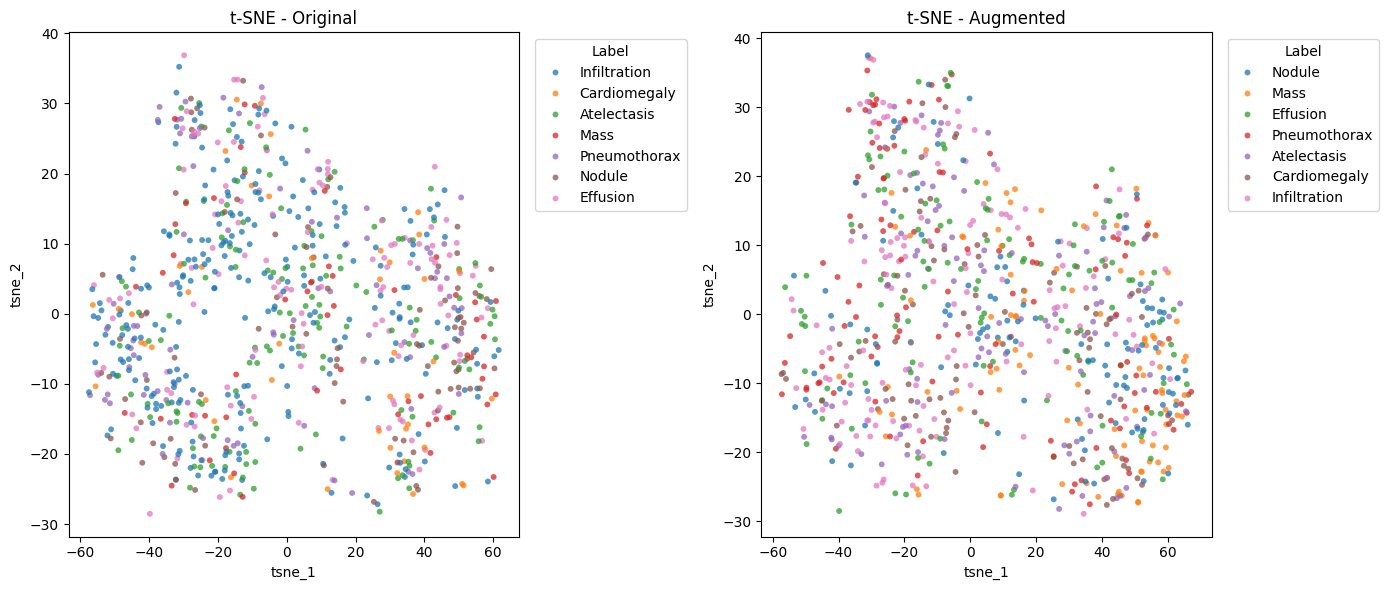

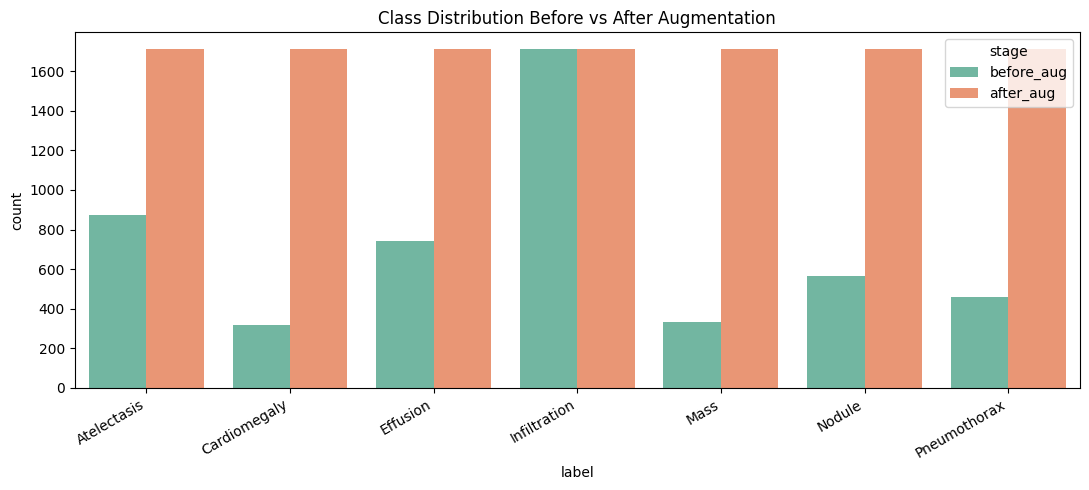

In [56]:
# =========================
# Data Augmentation + t-SNE Comparison
# =========================

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

SEED = 42
rng_aug = np.random.default_rng(SEED)


# -------------------------
# 1) Augmentation pipeline (5 transforms)
# -------------------------
def augment_image_pipeline(img: np.ndarray, rng: np.random.Generator) -> tuple[np.ndarray, list[str]]:
    h, w = img.shape
    out = img.copy()
    applied = []

    # 1. Horizontal flip
    if rng.random() < 0.5:
        out = cv2.flip(out, 1)
        applied.append("flip_h")

    # 2. Rotation
    if rng.random() < 0.7:
        angle = float(rng.uniform(-12.0, 12.0))
        m = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        out = cv2.warpAffine(
            out,
            m,
            (w, h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT_101,
        )
        applied.append("rotate")

    # 3. Random crop + resize back
    if rng.random() < 0.7:
        crop_scale = float(rng.uniform(0.85, 0.98))
        crop_h, crop_w = max(8, int(h * crop_scale)), max(8, int(w * crop_scale))
        y0 = int(rng.integers(0, h - crop_h + 1))
        x0 = int(rng.integers(0, w - crop_w + 1))
        out = out[y0:y0 + crop_h, x0:x0 + crop_w]
        out = cv2.resize(out, (w, h), interpolation=cv2.INTER_LINEAR)
        applied.append("random_crop")

    # 4. Add Gaussian noise
    if rng.random() < 0.7:
        sigma = float(rng.uniform(5.0, 12.0))
        noise = rng.normal(0.0, sigma, out.shape).astype(np.float32)
        out = np.clip(out.astype(np.float32) + noise, 0, 255).astype(np.uint8)
        applied.append("gaussian_noise")

    # 5. Brightness / contrast
    if rng.random() < 0.7:
        alpha = float(rng.uniform(0.85, 1.2))  # contrast
        beta = float(rng.uniform(-18, 18))      # brightness
        out = np.clip(alpha * out.astype(np.float32) + beta, 0, 255).astype(np.uint8)
        applied.append("brightness_contrast")

    # Guarantee at least one transform is applied
    if not applied:
        alpha = float(rng.uniform(0.9, 1.1))
        beta = float(rng.uniform(-10, 10))
        out = np.clip(alpha * out.astype(np.float32) + beta, 0, 255).astype(np.uint8)
        applied.append("brightness_contrast")

    return out, applied


# -------------------------
# 2) Build balanced augmented dataset
# -------------------------
df_labels_base = df_working[["Image Index", "Finding Labels"]].copy()
class_counts_before_aug = df_labels_base["Finding Labels"].value_counts().sort_index()
max_count = int(class_counts_before_aug.max())

augmented_image_dict = dict(shared_image_dict)
df_augmented_labels = df_labels_base.copy()

transform_usage = {
    "flip_h": 0,
    "rotate": 0,
    "random_crop": 0,
    "gaussian_noise": 0,
    "brightness_contrast": 0,
}

for label, count in class_counts_before_aug.items():
    needed = int(max_count - count)
    if needed <= 0:
        continue

    source_names = df_labels_base.loc[df_labels_base["Finding Labels"] == label, "Image Index"].tolist()
    if not source_names:
        continue

    for aug_idx in range(needed):
        src_name = str(rng_aug.choice(source_names))
        src_img = shared_image_dict.get(src_name)
        if src_img is None:
            continue

        aug_img, applied_ops = augment_image_pipeline(src_img, rng_aug)
        for op in applied_ops:
            transform_usage[op] += 1

        new_name = f"aug_{label}_{aug_idx}_{src_name}"
        augmented_image_dict[new_name] = aug_img
        df_augmented_labels.loc[len(df_augmented_labels)] = [new_name, label]

class_counts_after_aug = df_augmented_labels["Finding Labels"].value_counts().sort_index()

aug_num_generated = int(len(df_augmented_labels) - len(df_labels_base))
imbalance_before_aug = float(class_counts_before_aug.max() / class_counts_before_aug.min())
imbalance_after_aug = float(class_counts_after_aug.max() / class_counts_after_aug.min())

print_named_metric("aug_num_generated", aug_num_generated)
print_named_metric("imbalance_before_aug", round(imbalance_before_aug, 6))
print_named_metric("imbalance_after_aug", round(imbalance_after_aug, 6))
print("transform_usage:")
print(pd.Series(transform_usage).sort_values(ascending=False))

augmentation_comparison_table = pd.DataFrame(
    {
        "label": class_counts_before_aug.index,
        "before_aug": [int(class_counts_before_aug[label]) for label in class_counts_before_aug.index],
        "after_aug": [int(class_counts_after_aug[label]) for label in class_counts_before_aug.index],
    }
)
print("augmentation_comparison_table:")
print(augmentation_comparison_table)


# -------------------------
# 3) t-SNE feature comparison: original vs augmented
# -------------------------
def sample_features_with_labels(
    image_dict: dict[str, np.ndarray],
    labels_df: pd.DataFrame,
    max_samples: int,
    resize_dim: int,
    random_state: int,
    tag: str,
    ) -> tuple[np.ndarray, np.ndarray, list[str], list[str]]:
    valid_df = labels_df[labels_df["Image Index"].isin(image_dict.keys())].copy()
    if len(valid_df) == 0:
        return np.empty((0, resize_dim * resize_dim), dtype=np.float32), np.array([]), [], []

    n = min(max_samples, len(valid_df))
    sampled = valid_df.sample(n=n, random_state=random_state).reset_index(drop=True)

    feats, y, names = [], [], []
    for _, row in sampled.iterrows():
        img_name = row["Image Index"]
        img = image_dict.get(img_name)
        if img is None:
            continue
        img_rs = cv2.resize(img, (resize_dim, resize_dim), interpolation=cv2.INTER_AREA)
        feats.append(img_rs.astype(np.float32).flatten())
        y.append(row["Finding Labels"])
        names.append(img_name)

    x = np.asarray(feats, dtype=np.float32)
    y = np.asarray(y)
    tags = [tag] * len(y)
    return x, y, names, tags


tsne_max_samples_per_set = 800
tsne_resize_dim = 64

x_orig, y_orig, _, tag_orig = sample_features_with_labels(
    image_dict=shared_image_dict,
    labels_df=df_labels_base,
    max_samples=tsne_max_samples_per_set,
    resize_dim=tsne_resize_dim,
    random_state=SEED,
    tag="Original",
)

x_aug, y_aug, _, tag_aug = sample_features_with_labels(
    image_dict=augmented_image_dict,
    labels_df=df_augmented_labels,
    max_samples=tsne_max_samples_per_set,
    resize_dim=tsne_resize_dim,
    random_state=SEED,
    tag="Augmented",
)

tsne_num_original = int(len(x_orig))
tsne_num_augmented = int(len(x_aug))
print_named_metric("tsne_num_original", tsne_num_original)
print_named_metric("tsne_num_augmented", tsne_num_augmented)

if tsne_num_original > 1 and tsne_num_augmented > 1:
    x_all = np.vstack([x_orig, x_aug])
    y_all = np.concatenate([y_orig, y_aug])
    tag_all = np.array(tag_orig + tag_aug)

    x_all = StandardScaler().fit_transform(x_all)

    # PCA pre-reduction stabilizes and speeds up t-SNE
    pca_dim = min(50, x_all.shape[0], x_all.shape[1])
    x_all = PCA(n_components=pca_dim, random_state=SEED).fit_transform(x_all)

    perplexity = max(5, min(30, (x_all.shape[0] - 1) // 3))
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=perplexity, init="pca", learning_rate="auto")
    x_2d = tsne.fit_transform(x_all)

    df_tsne = pd.DataFrame(
        {
            "tsne_1": x_2d[:, 0],
            "tsne_2": x_2d[:, 1],
            "label": y_all,
            "set": tag_all,
        }
    )

    plt.figure(figsize=(14, 6))
    ax1 = plt.subplot(1, 2, 1)
    sns.scatterplot(
        data=df_tsne[df_tsne["set"] == "Original"],
        x="tsne_1",
        y="tsne_2",
        hue="label",
        s=18,
        alpha=0.75,
        linewidth=0,
        ax=ax1,
    )
    ax1.set_title("t-SNE - Original")
    ax1.legend(title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")

    ax2 = plt.subplot(1, 2, 2)
    sns.scatterplot(
        data=df_tsne[df_tsne["set"] == "Augmented"],
        x="tsne_1",
        y="tsne_2",
        hue="label",
        s=18,
        alpha=0.75,
        linewidth=0,
        ax=ax2,
    )
    ax2.set_title("t-SNE - Augmented")
    ax2.legend(title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()
else:
    print("Not enough samples to run t-SNE comparison.")


# -------------------------
# 4) Distribution plot
# -------------------------
plot_df = augmentation_comparison_table.melt(id_vars="label", var_name="stage", value_name="count")
plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="label", y="count", hue="stage", palette="Set2")
plt.title("Class Distribution Before vs After Augmentation")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Augmentation đã sinh thêm `6971` mẫu và kéo tỉ lệ mất cân bằng từ `5.397476` xuống `1.0`, giúp phân bố lớp đồng đều hơn cho huấn luyện.

Bảng `transform_usage` xác nhận pipeline đang dùng 5 phép biến đổi chính: lật ngang, xoay, cắt ngẫu nhiên, nhiễu Gaussian và điều chỉnh sáng/tương phản.

So sánh t-SNE giữa tập gốc và tập augment (`tsne_num_original`, `tsne_num_augmented`) cho phép quan sát tác động lên phân phối đặc trưng:
- Nếu các cụm lớp sau augment mở rộng nhưng vẫn giữ cấu trúc tách lớp tương đối ổn định, augmentation đang bổ sung đa dạng hữu ích.
- Nếu các cụm chồng lấn mạnh bất thường, cần giảm cường độ biến đổi (đặc biệt xoay/nhiễu/crop) để tránh làm méo đặc trưng chẩn đoán.

#### **e) PCA toàn tập, scree plot, và trực quan hóa PCA/t-SNE**
PCA cho phép chiếu dữ liệu ảnh từ không gian chiều cao xuống không gian thành phần chính để giữ lại phần lớn phương sai.


pca_full_num_samples: 5006
pca_full_num_features: 4096
pca_components_90: 45
pca_components_95: 120
pca_components_99: 633
pca_threshold_table:
   variance_target  required_components
0             0.90                   45
1             0.95                  120
2             0.99                  633


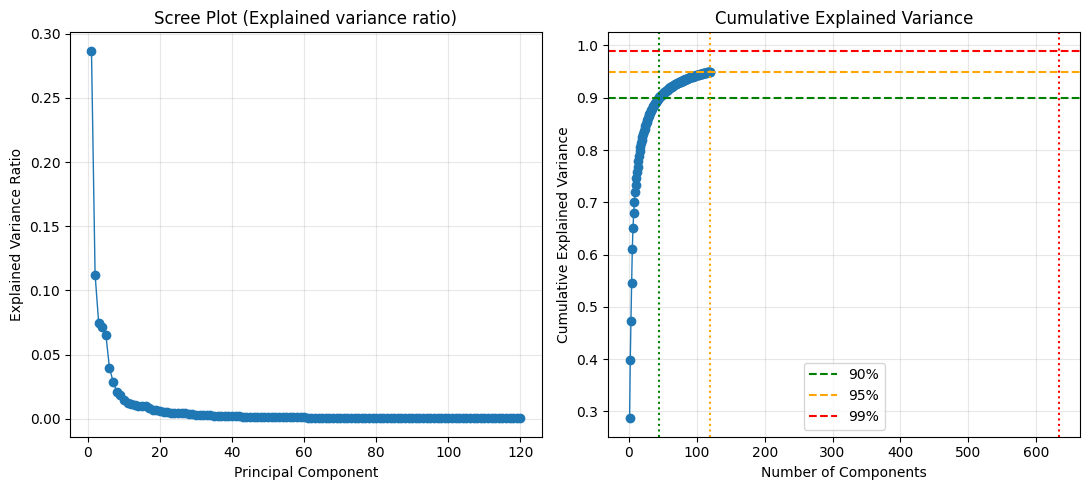

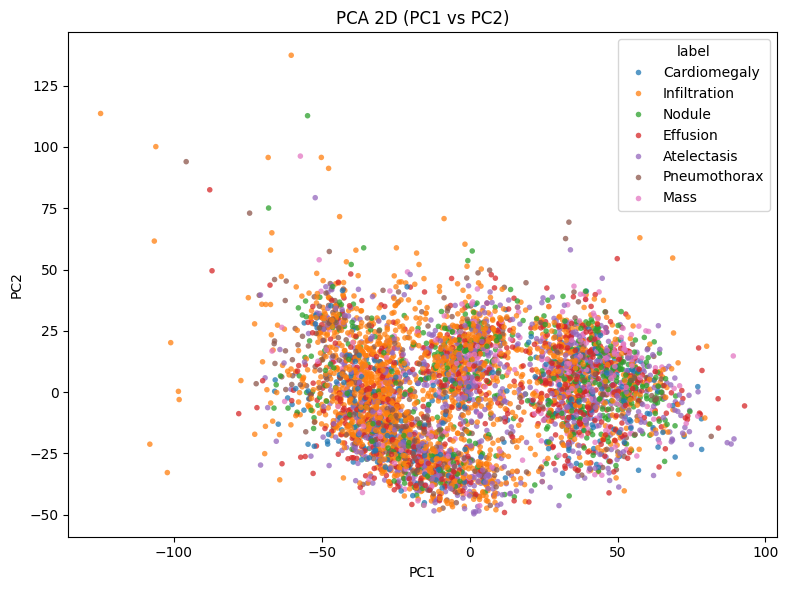

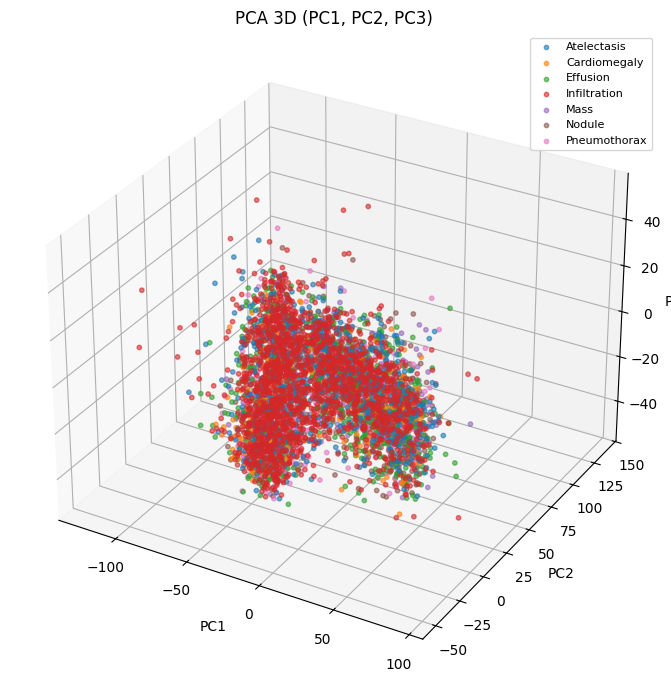

tsne_sample_size: 2000
tsne_perplexity: 30


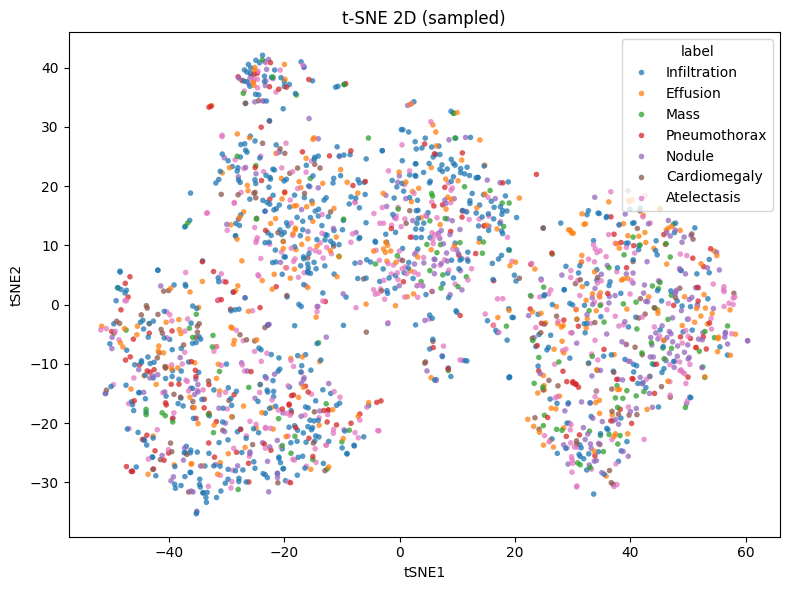

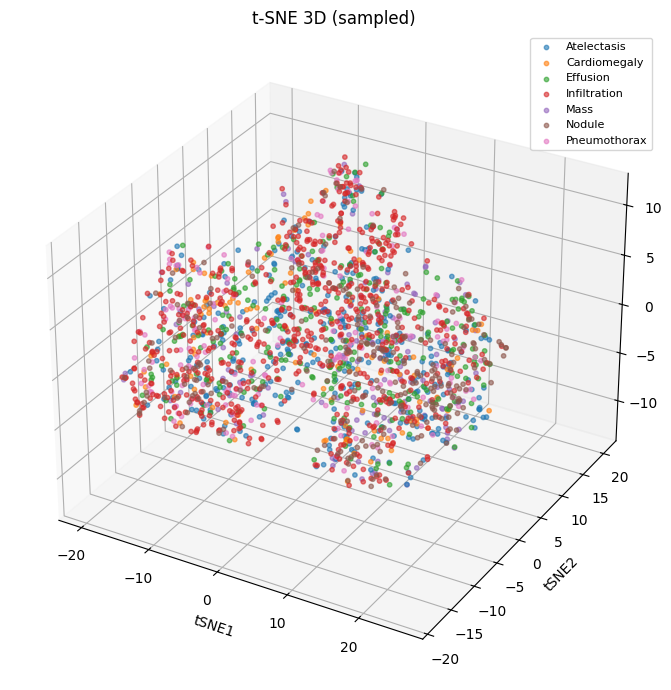

In [58]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


def build_feature_matrix(
    image_dict: dict[str, np.ndarray],
    labels_df: pd.DataFrame,
    resize_dim: int = 64,
) -> tuple[np.ndarray, np.ndarray, list[str]]:
    valid_df = labels_df[labels_df["Image Index"].isin(image_dict.keys())].copy().reset_index(drop=True)

    features = []
    labels = []
    names = []

    for _, row in valid_df.iterrows():
        name = row["Image Index"]
        img = image_dict.get(name)
        if img is None:
            continue

        img_rs = cv2.resize(img, (resize_dim, resize_dim), interpolation=cv2.INTER_AREA)
        features.append(img_rs.astype(np.float32).flatten())
        labels.append(row["Finding Labels"])
        names.append(name)

    x = np.asarray(features, dtype=np.float32)
    y = np.asarray(labels)
    return x, y, names


# 1) Build full feature space
pca_full_resize_dim = 64
x_full, y_full, name_full = build_feature_matrix(
    image_dict=shared_image_dict,
    labels_df=df_working[["Image Index", "Finding Labels"]].copy(),
    resize_dim=pca_full_resize_dim,
)

# 2) Standardize then PCA on full dataset
x_full_std = StandardScaler().fit_transform(x_full)
pca_full = PCA(random_state=SEED)
pca_full.fit(x_full_std)

explained_ratio = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)

pca_components_90 = int(np.searchsorted(cum_explained, 0.90) + 1)
pca_components_95 = int(np.searchsorted(cum_explained, 0.95) + 1)
pca_components_99 = int(np.searchsorted(cum_explained, 0.99) + 1)

print_named_metric("pca_full_num_samples", int(x_full.shape[0]))
print_named_metric("pca_full_num_features", int(x_full.shape[1]))
print_named_metric("pca_components_90", pca_components_90)
print_named_metric("pca_components_95", pca_components_95)
print_named_metric("pca_components_99", pca_components_99)

pca_threshold_table = pd.DataFrame(
    {
        "variance_target": [0.90, 0.95, 0.99],
        "required_components": [pca_components_90, pca_components_95, pca_components_99],
    }
)
print("pca_threshold_table:")
print(pca_threshold_table)

# 3) Scree plot + cumulative explained variance
max_plot_components = min(120, len(explained_ratio))
components_axis = np.arange(1, max_plot_components + 1)

plt.figure(figsize=(11, 5))
plt.subplot(1, 2, 1)
plt.plot(components_axis, explained_ratio[:max_plot_components], marker="o", linewidth=1)
plt.title("Scree Plot (Explained variance ratio)")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(components_axis, cum_explained[:max_plot_components], marker="o", linewidth=1)
plt.axhline(0.90, color="green", linestyle="--", label="90%")
plt.axhline(0.95, color="orange", linestyle="--", label="95%")
plt.axhline(0.99, color="red", linestyle="--", label="99%")
plt.axvline(pca_components_90, color="green", linestyle=":")
plt.axvline(pca_components_95, color="orange", linestyle=":")
plt.axvline(pca_components_99, color="red", linestyle=":")
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4) PCA 2D/3D visualization
pca_vis = PCA(n_components=3, random_state=SEED)
x_pca_3d = pca_vis.fit_transform(x_full_std)

df_pca_vis = pd.DataFrame(
    {
        "PC1": x_pca_3d[:, 0],
        "PC2": x_pca_3d[:, 1],
        "PC3": x_pca_3d[:, 2],
        "label": y_full,
    }
)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca_vis, x="PC1", y="PC2", hue="label", s=16, alpha=0.75, linewidth=0)
plt.title("PCA 2D (PC1 vs PC2)")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
for label in np.unique(y_full):
    part = df_pca_vis[df_pca_vis["label"] == label]
    ax.scatter(part["PC1"], part["PC2"], part["PC3"], s=10, alpha=0.6, label=label)
ax.set_title("PCA 3D (PC1, PC2, PC3)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

# 5) t-SNE 2D/3D visualization (sampled for speed)
tsne_sample_size = min(2000, len(x_full_std))
rng_tsne = np.random.default_rng(SEED)
tsne_idx = rng_tsne.choice(len(x_full_std), size=tsne_sample_size, replace=False)

x_tsne_in = x_full_std[tsne_idx]
y_tsne = y_full[tsne_idx]

# Pre-reduce to 50D before t-SNE for stability
x_tsne_in = PCA(n_components=min(50, x_tsne_in.shape[0], x_tsne_in.shape[1]), random_state=SEED).fit_transform(x_tsne_in)

tsne_perplexity = max(5, min(30, (len(x_tsne_in) - 1) // 3))

tsne_2d = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=tsne_perplexity,
    init="pca",
    learning_rate="auto",
)
embed_2d = tsne_2d.fit_transform(x_tsne_in)

tsne_3d = TSNE(
    n_components=3,
    random_state=SEED,
    perplexity=tsne_perplexity,
    init="pca",
    learning_rate="auto",
)
embed_3d = tsne_3d.fit_transform(x_tsne_in)

print_named_metric("tsne_sample_size", int(tsne_sample_size))
print_named_metric("tsne_perplexity", int(tsne_perplexity))


df_tsne_2d = pd.DataFrame(
    {
        "tSNE1": embed_2d[:, 0],
        "tSNE2": embed_2d[:, 1],
        "label": y_tsne,
    }
)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_tsne_2d, x="tSNE1", y="tSNE2", hue="label", s=16, alpha=0.75, linewidth=0)
plt.title("t-SNE 2D (sampled)")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
for label in np.unique(y_tsne):
    part = embed_3d[y_tsne == label]
    ax.scatter(part[:, 0], part[:, 1], part[:, 2], s=10, alpha=0.6, label=label)
ax.set_title("t-SNE 3D (sampled)")
ax.set_xlabel("tSNE1")
ax.set_ylabel("tSNE2")
ax.set_zlabel("tSNE3")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

##### **[Analysis]**
Kết quả từ `pca_threshold_table` trên toàn bộ tập dữ liệu (`pca_full_num_samples = 5006`, đặc trưng `64x64 -> 4096` chiều):
- Đạt **90%** phương sai cần `pca_components_90 = 45` thành phần.
- Đạt **95%** phương sai cần `pca_components_95 = 120` thành phần.
- Đạt **99%** phương sai cần `pca_components_99 = 633` thành phần.

Diễn giải:
- Mốc 90% đạt với số thành phần khá nhỏ (45), cho thấy phần lớn thông tin toàn cục có thể nén tương đối tốt.
- Để tăng từ 95% lên 99% cần thêm rất nhiều thành phần (120 -> 633), nghĩa là phần phương sai còn lại phân tán trên nhiều hướng nhỏ và có thể chứa chi tiết tinh vi/phi tuyến.

Mức độ tách biệt lớp qua trực quan hóa:
- **PCA 2D/3D**: xuất hiện một số cấu trúc cụm lớn, nhưng các nhãn lớp chồng lấn đáng kể. Điều này cho thấy chiếu tuyến tính chưa tạo ranh giới tách lớp rõ ràng.
- **t-SNE 2D/3D (sampled 2000 mẫu)**: hình học cụm cục bộ rõ hơn PCA, tuy nhiên màu nhãn vẫn xen lẫn trong nhiều vùng. Nghĩa là có cấu trúc phi tuyến, nhưng mức phân tách giữa bệnh lý vẫn chỉ ở mức trung bình.

Kết luận thực nghiệm:
- PCA phù hợp để giảm chiều trước mô hình cổ điển (ví dụ lấy 45-120 thành phần cho cân bằng nén thông tin).
- Riêng mục tiêu phân lớp bệnh lý vẫn khó do chồng lấn lớp cao; cần kết hợp thêm đặc trưng mạnh hơn hoặc mô hình phi tuyến/sâu và đánh giá bằng macro F1/accuracy ở bước downstream.